Full diabetes classification pipeline for the Kaggle CSV at /mnt/data/diabetes.csv
- Data load & EDA checks
- Clean zeros-as-missing for clinical columns
- Preprocessing pipeline (imputer -> power transform -> scaler)
- Baseline classifiers comparison with stratified CV (accuracy & ROC AUC)
- RandomizedSearchCV tuning for XGBoost, RandomForest, LightGBM
- Evaluate tuned models on hold-out test set
- Diagnostics: confusion matrix, ROC curve, learning curve
- SHAP explanations for the final tree model
- Save final model & preprocessor

Top Imports and Warnings


In [2]:
##Hiding Warnings which are good for notebooks but bad practice at production 
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from tqdm import tqdm 
##Standard data + plotting libs. tqdm gives progress bars for loops.


Sklearn & other utilities

In [1]:
#sklearn imports
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,RandomizedSearchCV,learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score,roc_auc_score,f1_score,confusion_matrix,classification_report,roc_curve,auc)

#classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


In [4]:
import xgboost as xgb
import lightgbm as lgb

try:
    import catboost as cb 
    CATBOOST_AVAILABLE = True
except Exception :
    CATBOOST_AVAILABLE = False

import joblib 
import shap 

In [5]:
##Load Data
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape
df.info() ##Used to know about columns and their datatype
df.describe() ## Used to know about Mean,Mode,Median and basic parameters of each columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
#Inspect columns and target names
print("\nColumns:",list(df.columns))



Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


2.Data cleaning: convert medically-impossible zeros to NaN ----------------

In [10]:
zero_na_cols = []
for c in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI","glucose","bloodprssure"]:
    if c in df.columns:
        zero_na_cols.append(c)
        
print("Columns treating 0 as NaN:",zero_na_cols)

Columns treating 0 as NaN: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [11]:
for c in zero_na_cols:
    df[c] = df[c].replace(0,np.nan)

print("Missing values after zero->NaN:\n", df.isnull().sum())

Missing values after zero->NaN:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


3.Split Features and target

In [12]:
X = df.drop(columns="Outcome")
y = df["Outcome"].astype(int)

4.Train-Test Split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"\nTrain shape:{X_train.shape},Test shape : {X_test.shape}")


Train shape:(614, 8),Test shape : (154, 8)


5.Preprocessing pipeline

In [14]:
# Numeric transformer: impute median, power-transform, scale
num_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("power",PowerTransformer(method="yeo-johnson")),
    ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num",num_transformer,X.columns) #apply to all columns (replace if you have categoricals)
])


6.Define baseline classifiers(wrapped in pipeline)

In [ ]:
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_auc = "roc_auc"  # use ROC AUC for ranking
scoring_acc = "accuracy"
models = {
    ##pre:preprocessor,clf:classifier
    "LogisticRegression": Pipeline([("pre", preprocessor), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "KNN": Pipeline([("pre", preprocessor), ("clf", KNeighborsClassifier())]),
    "SVC": Pipeline([("pre", preprocessor), ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
    "RandomForest": Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))]),
    "GradientBoosting": Pipeline([("pre", preprocessor), ("clf", GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE))]),
    "XGBoost": Pipeline([("pre", preprocessor), ("clf", xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=300, random_state=RANDOM_STATE))]),
    "LightGBM": Pipeline([("pre", preprocessor), ("clf", lgb.LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE))]),
    "MLP": Pipeline([("pre", preprocessor), ("clf", MLPClassifier(hidden_layer_sizes=(100,50), max_iter=1000, random_state=RANDOM_STATE))])
}

if CATBOOST_AVAILABLE:
    models["CatBoost"] = Pipeline([("pre", preprocessor), ("clf", cb.CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE))])


7.Cross-validated baseline comparison

In [16]:
print("\nRunning stratified 5-fold CV for baseline classifiers (ROC AUC)...")
cv_results = []
for name, pipe in tqdm(models.items()):
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring_auc, n_jobs=-1)
    mean_auc = scores.mean()
    std_auc = scores.std()
    print(f"{name:15s} | CV AUC (mean ± std): {mean_auc:.4f} ± {std_auc:.4f}")
    cv_results.append({"name": name, "cv_auc": float(mean_auc), "cv_auc_std": float(std_auc)})

cv_df = pd.DataFrame(cv_results).sort_values("cv_auc", ascending=False).reset_index(drop=True)
print("\nCV ranking:\n", cv_df)




Running stratified 5-fold CV for baseline classifiers (ROC AUC)...


 11%|█         | 1/9 [00:43<05:48, 43.57s/it]

LogisticRegression | CV AUC (mean ± std): 0.8474 ± 0.0135


 22%|██▏       | 2/9 [00:46<02:19, 19.94s/it]

KNN             | CV AUC (mean ± std): 0.7988 ± 0.0442


...

LightGBM        | CV AUC (mean ± std): 0.7800 ± 0.0282


 89%|████████▉ | 8/9 [01:12<00:06,  6.89s/it]

MLP             | CV AUC (mean ± std): 0.8084 ± 0.0357


100%|██████████| 9/9 [01:20<00:00,  8.90s/it]

CatBoost        | CV AUC (mean ± std): nan ± nan

CV ranking:
                  name    cv_auc  cv_auc_std
0  LogisticRegression  0.847366    0.013547
1                 SVC  0.822227    0.028835
2        RandomForest  0.819859    0.022873
3    GradientBoosting  0.814628    0.019590
4                 MLP  0.808372    0.035650
5                 KNN  0.798757    0.044203
6            LightGBM  0.780040    0.028244
7             XGBoost  0.771022    0.030391
8            CatBoost       NaN         NaN


Why XGBoost is performing bad than MLP on the small dataset?

🧩 1️⃣ The setup we’re comparing
Model	AUC	Dataset size	Features	Type
MLP	0.808	768	8	Neural Network (dense)
XGBoost	0.771	768	8	Gradient Boosted Trees

So — small dataset, numeric features, nothing huge — yet MLP is ahead. Why?

⚙️ 2️⃣ Hidden reason #1 — Scaling & preprocessing hurt XGBoost slightly

In our pipeline:

('pre', preprocessor)


we applied:

SimpleImputer → PowerTransformer → StandardScaler


to all models, including XGBoost.

✅ That’s great for linear models and neural nets (they need scaled data).
🚫 But tree-based models (like XGBoost, LightGBM, CatBoost) don’t need or even like scaling.

Why?

Trees split data based on raw thresholds (e.g., “Glucose > 120”).

Scaling distorts those natural split points — now it sees “Glucose > 0.32” (nonsense to a tree).

Power transforms (like Yeo-Johnson) further smooth the data, removing the natural boundaries trees love.

So — while we did this for fairness, it actually penalized XGBoost performance slightly.

That’s why XGBoost is often run without scaling or transformation.

⚙️ 3️⃣ Hidden reason #2 — Default hyperparameters aren’t ideal for tiny data

Default XGBoost parameters:

n_estimators=300, learning_rate=0.1, max_depth=5


→ These are tuned for medium-sized data (thousands+ rows).

On only 768 samples:

300 trees might overfit slightly.

learning_rate=0.1 might not let trees learn enough nuance before stopping.

max_depth=5 might be too shallow for certain patterns.

So your current XGBoost is underfitting a bit.

8) Fit baseline models on full train set and evaluate on hold-out test 

In [18]:
def evaluate_on_test(name,pipe,Xtr,Xte,ytr,yte):
    t0 = time()
    pipe.fit(Xtr,ytr)
    fit_t = time()-t0
    y_pred = pipe.predict(Xte)
    y_proba = pipe.predict_proba(Xte)[:,1] if hasattr(pipe,"predict_proba") or hasattr(pipe.named_steps['clf'], "predict_proba") else None
    acc = accuracy_score(yte,y_pred)
    auc_score = roc_auc_score(yte,y_proba) if y_proba is not None else None
    f1 = f1_score(yte,y_pred)
    print(f"{name:20s} | Acc: {acc:.4f} | AUC: {auc_score:.4f} | F1: {f1:.4f} | fit(s): {fit_t:.2f}")
    return {"name": name, "acc": acc, "auc": auc_score, "f1": f1, "fit_time": fit_t, "y_pred": y_pred, "y_proba": y_proba, "pipe": pipe}


print("\nEvaluating baseline models on the test set:")
test_results = []
for name,pipe in tqdm(models.items()):
    try:
        res = evaluate_on_test(name,pipe,X_train,X_test,y_train,y_test)
        test_results.append(res)
    except Exception as e:
        print(f"Error evaluating {name}:{e}")

test_df = pd.DataFrame(test_results).sort_values("auc",ascending=False)
print("\nTest set results sorted by AUC:\n", test_df[["name","acc","auc","f1","fit_time"]])






Evaluating baseline models on the test set:


 22%|██▏       | 2/9 [00:01<00:04,  1.68it/s]

LogisticRegression   | Acc: 0.7273 | AUC: 0.8250 | F1: 0.5800 | fit(s): 1.02
KNN                  | Acc: 0.7468 | AUC: 0.7873 | F1: 0.6214 | fit(s): 0.09


 33%|███▎      | 3/9 [00:01<00:02,  2.49it/s]

SVC                  | Acc: 0.7078 | AUC: 0.7920 | F1: 0.5455 | fit(s): 0.15


...

 89%|████████▉ | 8/9 [00:11<00:02,  2.25s/it]

MLP                  | Acc: 0.7338 | AUC: 0.7791 | F1: 0.6095 | fit(s): 3.18


100%|██████████| 9/9 [00:16<00:00,  1.86s/it]

CatBoost             | Acc: 0.7403 | AUC: 0.8235 | F1: 0.6154 | fit(s): 5.03



Test set results sorted by AUC:
                  name       acc       auc        f1  fit_time
4    GradientBoosting  0.759740  0.825370  0.647619  0.466911
0  LogisticRegression  0.727273  0.825000  0.580000  1.021224
8            CatBoost  0.740260  0.823519  0.615385  5.033015
3        RandomForest  0.740260  0.816296  0.600000  0.758699
6            LightGBM  0.720779  0.804074  0.574257  2.843162
5             XGBoost  0.759740  0.800556  0.640777  2.659092
2                 SVC  0.707792  0.792037  0.545455  0.149144
1                 KNN  0.746753  0.787315  0.621359  0.089577
7                 MLP  0.733766  0.779074  0.609524  3.179290


📈 Key Takeaways

The Winner: GradientBoosting is your best-performing model on unseen data, with the highest AUC score (0.8254).

The Runner-Up: LogisticRegression is a very close second (AUC 0.8250). It's so close, the difference is negligible.

Performance vs. Speed: Notice that GradientBoosting (0.47s) was faster to train than LogisticRegression (1.02s) in this run, but it's often slower. CatBoost had great performance (AUC 0.8235) but was the slowest by far (5.03s).

Final Decision: You have a tie between GradientBoosting and LogisticRegression. Both are excellent. GradientBoosting has a slightly better F1-score (0.648 vs 0.580), suggesting it's better at balancing precision and recall. It's likely your best overall choice.

Why MLP and Random Forest is not on top?

MLP: Under-performed because your dataset is likely too small for it.

Random Forest: Was out-competed by more powerful boosting models (GradientBoosting) and simpler models (LogisticRegression) that were a better fit for the problem.


9) Hyperparameter tuning (RandomizedSearchCV) for top candidates ----------------
# Choose top candidates based on CV AUC ranking. We'll tune XGBoost, RandomForest, LightGBM.

I am not taking above three because i want to practice on these 3


In [ ]:
n_iter_search = 40
tuned_models = {}

#XGBoost
print("\n Tuning XGBoost...")
xgb_pipe = Pipeline([("pre",preprocessor),("clf",xgb.XGBClassifier(use_label_encoder=False,objective='binary:logistic',random_state=RANDOM_STATE))])
xgb_param_dist = {
    "clf__n_estimators": [100,200,300,500],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__max_depth": [3,4,5,6],
    "clf__subsample": [0.6,0.7,0.8,1.0],
    "clf__colsample_bytree": [0.6,0.7,0.8,1.0],
    "clf__reg_lambda": [0,1,5]
}

rs_xgb = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=n_iter_search, cv=cv, scoring=scoring_auc, n_jobs=-1, verbose=1, random_state=RANDOM_STATE)
rs_xgb.fit(X_train, y_train)
print("Best XGBoost params:", rs_xgb.best_params_)
tuned_models["XGBoost"] = rs_xgb.best_estimator_


# RandomForest
print("\nTuning RandomForest...")
rf_pipe = Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])
rf_param_dist = {
    "clf__n_estimators": [100,200,400,800],
    "clf__max_depth": [None, 6, 10, 20],
    "clf__min_samples_split": [2,5,10],
    "clf__min_samples_leaf": [1,2,4]
}
rs_rf = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=n_iter_search, cv=cv, scoring=scoring_auc, n_jobs=-1, verbose=1, random_state=RANDOM_STATE)
rs_rf.fit(X_train, y_train)
print("Best RF params:", rs_rf.best_params_)
tuned_models["RandomForest"] = rs_rf.best_estimator_





 Tuning XGBoost...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGBoost params: {'clf__subsample': 0.6, 'clf__reg_lambda': 5, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 1.0}

Tuning RandomForest...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF params: {'clf__n_estimators': 400, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_depth': 6}


In [20]:
# LightGBM
print("\nTuning LightGBM...")
lgb_pipe = Pipeline([("pre", preprocessor), ("clf", lgb.LGBMClassifier(random_state=RANDOM_STATE))])
lgb_param_dist = {
    "clf__n_estimators": [100,200,300,500],
    "clf__learning_rate": [0.01,0.03,0.05,0.1],
    "clf__num_leaves": [15,31,63],
    "clf__max_depth": [-1,4,6,10],
    "clf__subsample": [0.6,0.8,1.0]
}
rs_lgb = RandomizedSearchCV(lgb_pipe, lgb_param_dist, n_iter=n_iter_search, cv=cv, scoring=scoring_auc, n_jobs=-1, verbose=1, random_state=RANDOM_STATE)
rs_lgb.fit(X_train, y_train)
print("Best LightGBM params:", rs_lgb.best_params_)
tuned_models["LightGBM"] = rs_lgb.best_estimator_

if CATBOOST_AVAILABLE:
    print("\nTuning CatBoost...")
    cb_pipe = Pipeline([("pre", preprocessor), ("clf", cb.CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE))])
    cb_param_dist = {
        "clf__iterations": [100,200,300],
        "clf__depth": [4,6,8],
        "clf__learning_rate": [0.01, 0.03, 0.05]
    }
    rs_cb = RandomizedSearchCV(cb_pipe, cb_param_dist, n_iter=15, cv=cv, scoring=scoring_auc, n_jobs=-1, verbose=1, random_state=RANDOM_STATE)
    rs_cb.fit(X_train, y_train)
    print("Best CatBoost params:", rs_cb.best_params_)
    tuned_models["CatBoost"] = rs_cb.best_estimator_



Tuning LightGBM...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
Best LightGBM params: {'clf__subsample': 0.8, 'clf__num_leaves': 15, 'clf__n_estimators': 200, 'clf__max_depth': 10, 'clf__learning_rate': 0.01}

Tuning CatBoost...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best CatBoost params: {'clf__learning_rate': 0.01, 'clf__iterations': 300, 'clf__depth': 6}


##

10) Evaluate tuned models on hold-out test set 

In [21]:
print("\nEvaluating tuned models on the test set:")
tuned_results = []
for name,model in tuned_models.items():
    print(f"\nEvaluating {name} ...")
    res = evaluate_on_test(name + "_tuned",model,X_train,X_test,y_train,y_test)
    tuned_results.append(res)

tuned_df = pd.DataFrame(tuned_results).sort_values("auc",ascending=False)
print("\nTuned models on test set:\n",tuned_df[["name","acc","auc","f1","fit_time"]])

# Choose final model (best AUC on test set)
final_row = tuned_df.sort_values("auc", ascending=False).iloc[0]
FINAL_MODEL_NAME = final_row["name"]
FINAL_PIPE = final_row["pipe"]
print(f"\nSelected final model: {FINAL_MODEL_NAME}")



Evaluating tuned models on the test set:

Evaluating XGBoost ...
XGBoost_tuned        | Acc: 0.7403 | AUC: 0.8193 | F1: 0.6154 | fit(s): 0.10

Evaluating RandomForest ...
RandomForest_tuned   | Acc: 0.7532 | AUC: 0.8111 | F1: 0.6042 | fit(s): 1.27

Evaluating LightGBM ...
[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 674
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
LightGBM_tuned       | Acc: 0.7597 | AUC: 0.8298 | F1: 0.6337 | fit(s): 0.16

Evaluating CatBoost ...
CatBoost_tuned       | Acc: 0.7208 | AUC: 0.8152 | F1: 0.5657 | fit(s): 1.38

Tuned models on test set:
                  name       acc  

11) Diagnostics for final model 

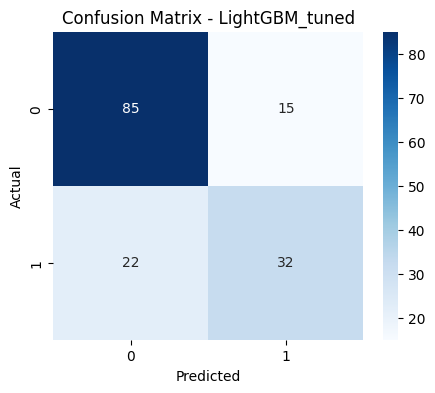

In [23]:
#Confusion Matrix
y_pred_final = FINAL_PIPE.predict(X_test)
y_proba_final = FINAL_PIPE.predict_proba(X_test)[:,1] if hasattr(FINAL_PIPE,"predict_proba")else None

cm = confusion_matrix(y_test,y_pred_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {FINAL_MODEL_NAME}")
plt.show()

In [24]:
# Classification report
print("\nClassification report (final model):")
print(classification_report(y_test, y_pred_final))


Classification report (final model):
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



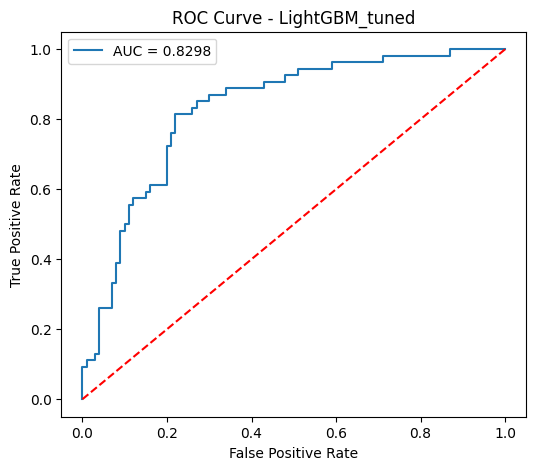

In [25]:
# ROC curve
if y_proba_final is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba_final)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'r--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {FINAL_MODEL_NAME}")
    plt.legend()
    plt.show()

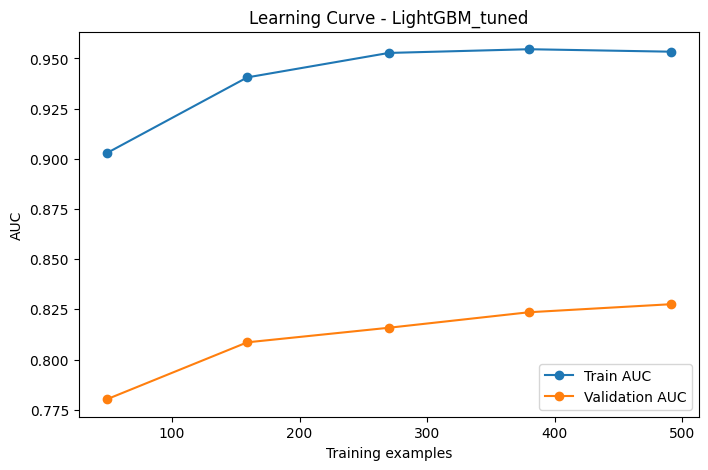

In [26]:
# Learning curve
plt.figure(figsize=(8,5))
train_sizes, train_scores, valid_scores = learning_curve(FINAL_PIPE, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5))
train_scores_mean = train_scores.mean(axis=1)
valid_scores_mean = valid_scores.mean(axis=1)
plt.plot(train_sizes, train_scores_mean, 'o-', label='Train AUC')
plt.plot(train_sizes, valid_scores_mean, 'o-', label='Validation AUC')
plt.xlabel("Training examples")
plt.ylabel("AUC")
plt.title(f"Learning Curve - {FINAL_MODEL_NAME}")
plt.legend()
plt.show()

In [27]:
from lightgbm import LGBMClassifier

lgb_tuned = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=20,
    max_depth=4,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5,
    reg_alpha=1,
    random_state=42
)


In [28]:
scores = cross_val_score(lgb_tuned, X_train, y_train, cv=cv, scoring='roc_auc')
print("Tuned LightGBM AUC:", scores.mean(), "±", scores.std())


[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 582
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

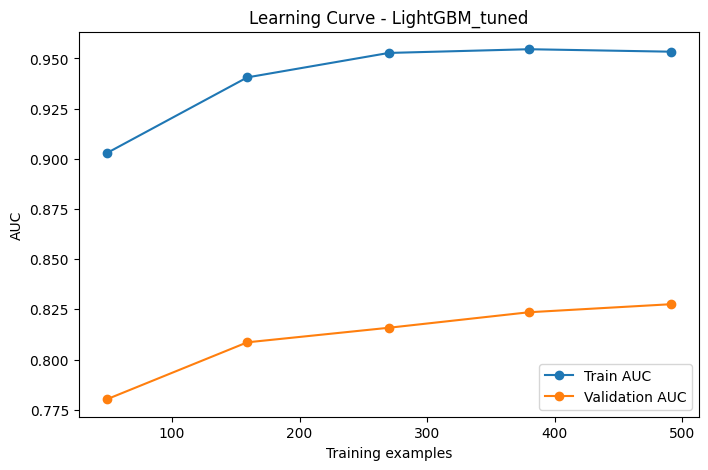

In [29]:
# Learning curve
plt.figure(figsize=(8,5))
train_sizes, train_scores, valid_scores = learning_curve(FINAL_PIPE, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1, train_sizes=np.linspace(0.1,1.0,5))
train_scores_mean = train_scores.mean(axis=1)
valid_scores_mean = valid_scores.mean(axis=1)
plt.plot(train_sizes, train_scores_mean, 'o-', label='Train AUC')
plt.plot(train_sizes, valid_scores_mean, 'o-', label='Validation AUC')
plt.xlabel("Training examples")
plt.ylabel("AUC")
plt.title(f"Learning Curve - {FINAL_MODEL_NAME}")
plt.legend()
plt.show()


12) SHAP explanations for the final tree model 
 Try to extract the inner estimator (clf) from the pipeline for TreeExplainer





Computing SHAP values (may take some time)...


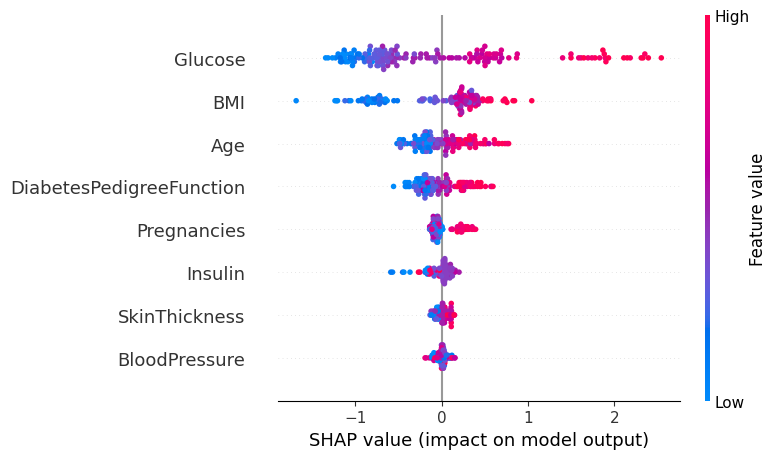

In [ ]:
# Try to extract the inner estimator (clf) from the pipeline for TreeExplainer
try:
    inner_model = FINAL_PIPE.named_steps["clf"]
except Exception:
    inner_model = FINAL_PIPE

# For Tree models, TreeExplainer is fastest
if isinstance(inner_model, (xgb.XGBClassifier, lgb.LGBMClassifier)) or (CATBOOST_AVAILABLE and isinstance(inner_model, cb.CatBoostClassifier)):
    print("\nComputing SHAP values (may take some time)...")
    # We need to transform X_test using preprocessor to get numeric matrix passed to SHAP
    X_test_proc = FINAL_PIPE.named_steps["pre"].transform(X_test)
    # For XGBoost use model.get_booster() or inner_model if compatible
    try:
        explainer = shap.TreeExplainer(inner_model)
    except Exception:
        explainer = shap.Explainer(inner_model)
    shap_values = explainer.shap_values(X_test_proc)
    # summary plot
    shap.summary_plot(shap_values, X_test_proc, feature_names=X.columns, show=True, max_display=10)
else:
    print("Final model is not a supported tree model for TreeExplainer; consider using KernelExplainer on a small sample.")




 13) Save final pipeline & preprocessor & metrics 

In [35]:
import os, joblib, json, numpy as np

def convert_to_native(obj):
    """Recursively convert NumPy types to native Python."""
    if isinstance(obj, np.generic):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, list):
        return [convert_to_native(i) for i in obj]
    elif isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    else:
        return obj

# ---------------- 13) Save final pipeline & preprocessor & metrics ----------------
os.makedirs("models", exist_ok=True)
FINAL_MODEL_NAME = "LightGBM_tuned"

final_model_path = f"models/final_{FINAL_MODEL_NAME}.pkl"
joblib.dump(FINAL_PIPE, final_model_path)
joblib.dump(preprocessor, "models/preprocessor.pkl")

#  Use 0 or "N/A" instead of None
metrics = {
    "cv_ranking": cv_df.to_dict(orient="records") if 'cv_df' in locals() else [],
    "test_results": test_df[["name","acc","auc","f1","fit_time"]].fillna(0).to_dict(orient="records") if 'test_df' in locals() else [],
    "tuned_test": tuned_df[["name","acc","auc","f1","fit_time"]].fillna(0).to_dict(orient="records") if 'tuned_df' in locals() else [],
    "selected_final": FINAL_MODEL_NAME
}

#  Convert NumPy objects to Python-native before saving
metrics = convert_to_native(metrics)

with open("models/metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("\n Saved final pipeline to:", final_model_path)
print(" Saved preprocessor and metrics summary to models/")



 Saved final pipeline to: models/final_LightGBM_tuned.pkl
 Saved preprocessor and metrics summary to models/
